In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda:0')

import os, json, pickle
import numpy as np
import transformers
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig

import pandas as pd
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
SEQUENCE_MASK_TOKEN = tokenizer.mask_token_id
config = AutoConfig.from_pretrained('facebook/esm2_t33_650M_UR50D')
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t33_650M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

Loaded BERT Model


In [2]:
from Bio import SeqIO
sequences = [str(s.seq).upper() for s in SeqIO.parse('../../data/disordered_prot.fasta', 'fasta')]

In [3]:
vi = {i: a for a, i in tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]

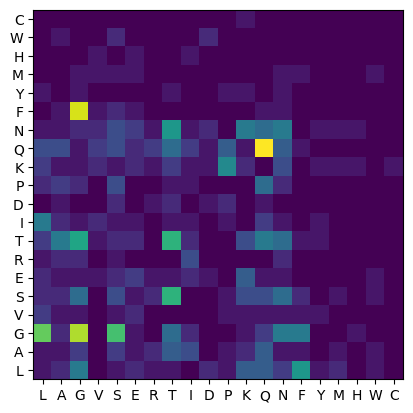

In [4]:
num_tok = len(tokenizer.get_vocab())
def seq_kmers(seq_ind):
    kmer_stats = torch.zeros(num_tok, num_tok)
    sp = torch.stack([seq_ind[:-1], seq_ind[1:]])
    for i in range(sp.shape[1]):
        kmer_stats[sp[0, i], sp[1, i]] += 1
    return kmer_stats

seq_ind = torch.LongTensor(tokenizer.encode(sequences[0]))
kmer_tensor = seq_kmers(seq_ind)
import matplotlib.pyplot as plt
plt.imshow(kmer_tensor[4:24, 4:24], origin='lower')
plt.xticks(np.arange(0, 20), list(AA_str))
plt.yticks(np.arange(0, 20), list(AA_str))
plt.show()

In [5]:
from go_ml.masking import *

In [6]:
def kmer_mask(seq_ind, mask_token=SEQUENCE_MASK_TOKEN, k=3):
    seq_len = seq_ind.shape[0] - 2 #Discount first and last tokens
    batch = torch.tile(seq_ind, (seq_len-k+1, 1))
    batch_ind = torch.arange(batch.shape[0])
    mut_ind = batch_ind + 1
    col_ind = torch.arange(seq_ind.shape[0]).reshape(1, -1)
    col_ind = torch.tile(col_ind, (batch.shape[0], 1))
    mut_delta = col_ind - mut_ind.reshape(-1, 1)
    # print(mut_delta)
    mut_mask = (0 <= mut_delta) & (mut_delta < k)
    mut_mask[:, 0] = False; mut_mask[:, -1] = False #Don't mess with sos, eos tokens
    batch[mut_mask] = mask_token
    return batch, batch_ind, mut_ind
# batch, batch_ind, mut_ind = kmer_mask(seq_ind[:23], mask_token=SEQUENCE_MASK_TOKEN, k=5)

In [ ]:
def kmer_mask_stats(seq, k=3, batch_size=16, mask_func=kmer_mask):
    seq_ind = torch.LongTensor(tokenizer.encode(seq)).to(device)
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(x)
            bert_eval = model_eval.logits
            bert_eval_l.append(bert_eval)
    bert_eval = torch.cat(bert_eval_l)
    bert_eval = torch.softmax(bert_eval, dim=2)
    
    print(bert_eval.shape)

    one_hot_eval = torch.eye(len(tokenizer.get_vocab())).to(device)[batch]
    N, L = batch.shape
    batch_mask = (batch == SEQUENCE_MASK_TOKEN).reshape(N, L, 1)
    mixed_eval = (~batch_mask)*one_hot_eval + batch_mask*bert_eval

    kmer_tensor = torch.zeros([20]*k).to(device)
    for i in range(batch.shape[0]):
        for si in range(1, batch.shape[1]-k-1):
            num_masked = batch_mask[i, si:si+k, 0].sum() 
            if(num_masked <= 4 and num_masked > 2):
                kmer_axes = mixed_eval[i, si, 4:24]
                for eval_ind in range(1, k):
                    # print(si, eval_ind, k)
                    kmer_axes = torch.kron(kmer_axes, mixed_eval[i, si+eval_ind, 4:24]) 
                kmer_tensor += kmer_axes.reshape(kmer_tensor.shape)
    return kmer_tensor

# kmer_stats = kmer_mask_stats(sequences[-1], k=4, batch_size=16, mask_func=lambda s, m: mask_perc(s, m, residue_coverage=12))
# kmer_stats_2mer = kmer_mask_stats(sequences[1], k=2, batch_size=16, mask_func=lambda s, m: mask_perc(s, m, residue_coverage=12))
# kmer_stats_5mer = kmer_mask_stats(sequences[0], k=5, batch_size=16, mask_func=lambda s, m: mask_perc(s, m, residue_coverage=24, mut_per=0.30))
kmer_stats_4mer = kmer_mask_stats(sequences[-1], k=4, batch_size=16, mask_func=lambda s, m: mask_perc(s, m, residue_coverage=12))
# kmer_stats = kmer_mask_stats(sequences[-1], k=4, batch_size=16)

torch.Size([80, 1356, 33])


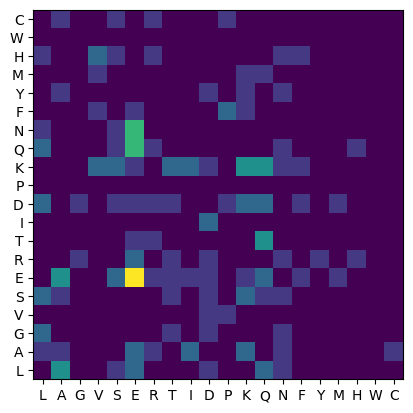

In [8]:
def seq_kmers(sequence, k=3):
    seq_ind = torch.LongTensor(tokenizer.encode(sequence))
    kmer_stats = torch.zeros([20]*k)
    # sp = torch.stack([seq_ind[:-1], seq_ind[1:]])
    for i in range(1, 1+len(sequence)-k):
        kmer_ind = tuple(seq_ind[i:i+k]-4)
        kmer_stats[kmer_ind] += 1
    return kmer_stats
base_kmer_stats_4mer = seq_kmers(sequences[-1], 4)

plt.imshow(base_kmer_stats_4mer.sum(dim=1).cpu().numpy()[0], origin='lower')
plt.xticks(np.arange(20), AA_str)
plt.yticks(np.arange(20), AA_str)
plt.show()

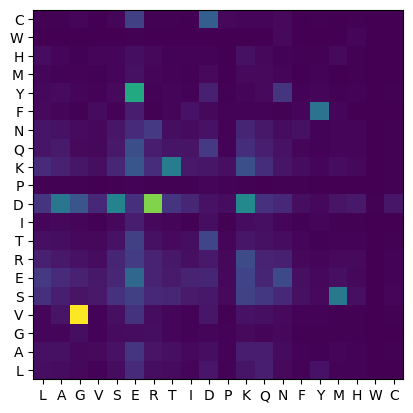

In [10]:
a = kmer_stats_4mer[0, 0].cpu().numpy()
plt.imshow(a, origin='lower')
plt.xticks(np.arange(20), AA_str)
plt.yticks(np.arange(20), AA_str)
plt.show()

In [7]:
aa_ind = {a:i for i, a in enumerate(AA_str)}
# print([aa_ind[r] for r in 'PNPDY'])
print([aa_ind[r] for r in 'DETDG'])

[9, 5, 7, 9, 2]


In [ ]:
def mask_batch(seq_batch, mut_per=0.15):
    batch_size, seq_len = seq_batch.shape
    seq_len = torch.LongTensor([seq_len - 2]) #Discount SOS and EOS tokens at start and end
    mut_count = torch.floor(seq_len*mut_per).int().item()
    mut_inds = torch.stack([torch.randperm(seq_len) for _ in range(batch_size)])[:, :mut_count] + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)
    update_batch = seq_batch.clone()
    update_batch[batch_inds, mut_inds] = SEQUENCE_MASK_TOKEN
    return update_batch

def batch_sample(seq_batch):
    update_batch = mask_batch(seq_batch)
    with torch.no_grad():
        model_eval = model(update_batch)
        bert_eval = model_eval.logits
        bert_eval = torch.softmax(bert_eval, dim=2)
        N, L, T = bert_eval.shape
    sample_tokens = torch.multinomial(bert_eval.reshape(N*L, T), num_samples=1).reshape(N, L)
    update_batch[seq_batch == SEQUENCE_MASK_TOKEN] = sample_tokens
    return update_batch, bert_eval

def gibbs_sampler(seq, mut_per=0.15, num_iter=16, batch_size=8):
    seq_ind = torch.LongTensor(tokenizer.encode(seq)).to(device)
    mask_batch_sample_l = []
    batch_sample_l = [] 
    bert_eval_l = []
    seq_batch = torch.tile(seq_ind.reshape(1, -1), (batch_size, 1))
    with torch.no_grad():
        for _ in range(num_iter):
            update_batch = mask_batch(seq_batch, mut_per=mut_per)
            batch_sample_l.append(seq_batch.cpu())            
            mask_batch_sample_l.append(update_batch.cpu()) #Save masked batch
            model_eval = model(update_batch)
            bert_eval = model_eval.logits
            bert_eval = torch.softmax(bert_eval, dim=2)
            N, L, T = bert_eval.shape
            sample_tokens = torch.multinomial(bert_eval.reshape(N*L, T), num_samples=1).reshape(N, L)
            # print(bert_eval.shape)
            # print(sample_tokens.shape)
            # print(update_batch.shape)
            # print((update_batch == SEQUENCE_MASK_TOKEN).shape)
            update_batch = update_batch * (update_batch != SEQUENCE_MASK_TOKEN) + sample_tokens * (update_batch == SEQUENCE_MASK_TOKEN)
            bert_eval_l.append(bert_eval.cpu())
            seq_batch = update_batch

    return torch.stack(bert_eval_l), torch.stack(batch_sample_l), torch.stack(mask_batch_sample_l)

ind = 2
gibbs_eval, gibbs_batch, gibbs_batch_mask = gibbs_sampler(sequences[ind], mut_per=0.15, num_iter=25, batch_size=12)
base_seq = torch.LongTensor(tokenizer.encode(sequences[ind]))
hamming_drift = (gibbs_batch != base_seq.reshape(1, 1, -1)).sum(dim=-1)
for i in range(hamming_drift.shape[1]):
    plt.plot(hamming_drift[:, i] / base_seq.shape[0])
plt.show()

In [16]:
from go_ml.masking import *
def get_logits(seq, batch_size=8, mask_func=mask_indiv):
    seq_ind = torch.LongTensor(tokenizer.encode(seq)).to(device)
    ln = len(seq)
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(x)
            bert_eval = model_eval.logits
            bert_eval_l.append(bert_eval.cpu())
    bert_eval = torch.cat(bert_eval_l)
    bert_eval = torch.softmax(bert_eval, dim=2)
    bert_mask = (batch == SEQUENCE_MASK_TOKEN).cpu()
    eval_avg, eval_support = mask_avg(bert_mask, bert_eval)
    return eval_avg

tf_logits = get_logits(sequences[-1], batch_size=16, mask_func=lambda a, b: mask_perc(a, b, 6, 0.05))
# tf_logits = get_logits(sequences[-1], batch_size=16, mask_func=mask_indiv)
tf_logits = tf_logits[:, 4:24]
# tf_logits = torch.softmax(tf_logits[:, 4:24], dim=1)

In [13]:
sequences[-1]

'MSTGDSFETRFEKMDNLLRDPKSEVNSDCLLDGLDALVYDLDFPALRKNKNIDNFLSRYKDTINKIRDLRMKAEDYEVVKVIGRGAFGEVQLVRHKSTRKVYAMKLLSKFEMIKRSDSAFFWEERDIMAFANSPWVVQLFYAFQDDRYLYMVMEYMPGGDLVNLMSNYDVPEKWARFYTAEVVLALDAIHSMGFIHRDVKPDNMLLDKSGHLKLADFGTCMKMNKEGMVRCDTAVGTPDYISPEVLKSQGGDGYYGRECDWWSVGVFLYEMLVGDTPFYADSLVGTYSKIMNHKNSLTFPDDNDISKEAKNLICAFLTDREVRLGRNGVEEIKRHLFFKNDQWAWETLRDTVAPVVPDLSSDIDTSNFDDLEEDKGEEETFPIPKAFVGNQLPFVGFTYYSNRRYLSSANPNDNRTSSNADKSLQESLQKTIYKLEEQLHNEMQLKDEMEQKCRTSNIKLDKIMKELDEEGNQRRNLESTVSQIEKEKMLLQHRINEYQRKAEQENEKRRNVENEVSTLKDQLEDLKKVSQNSQLANEKLSQLQKQLEEANDLLRTESDTAVRLRKSHTEMSKSISQLESLNRELQERNRILENSKSQTDKDYYQLQAILEAERRDRGHDSEMIGDLQARITSLQEEVKHLKHNLEKVEGERKEAQDMLNHSEKEKNNLEIDLNYKLKSLQQRLEQEVNEHKVTKARLTDKHQSIEEAKSVAMCEMEKKLKEEREAREKAENRVVQIEKQCSMLDVDLKQSQQKLEHLTGNKERMEDEVKNLTLQLEQESNKRLLLQNELKTQAFEADNLKGLEKQMKQEINTLLEAKRLLEFELAQLTKQYRGNEGQMRELQDQLEAEQYFSTLYKTQVKELKEEIEEKNRENLKKIQELQNEKETLATQLDLAETKAESEQLARGLLEEQYFELTQESKKAASRNRQEITDKDHTVSRLEEANSMLTKDIEILRRENEELTEKMKKAEEEYKLEKEEEISNLKAAFEKNINTERTLK

In [18]:
seq_ind = torch.LongTensor(tokenizer.encode(sequences[-1])) - 4
(seq_ind== tf_logits.argmax(dim=1)).float().mean()

tensor(0.5339)

tensor([4, 4, 0, 0, 5, 4])
['S', 'S', 'L', 'L', 'E', 'S']


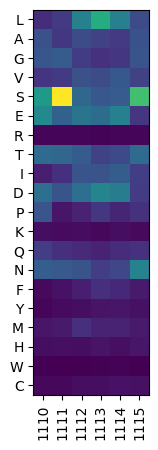

In [19]:
si = sequences[-1].index("DETDG") + 1
ei = si+6
print(tf_logits[si:ei, :].argmax(dim=1))
print([AA_str[x] for x in tf_logits[si:ei].argmax(dim=1).numpy()])
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

si = si
ei = si+6
plt.imshow(tf_logits[si:ei].cpu().numpy().T)
ax.set_yticks(np.arange(0, 20), list(AA_str))
ax.set_xticks(np.arange(0, ei-si), np.arange(si, ei), rotation=90)
plt.show()


In [24]:
sequences[1].index("PRVSL")
tf_logits[486:491].argmax(dim=1)
[i for i in range(10)]
[AA_str[x] for x in tf_logits[486:491].argmax(dim=1).numpy()]


ValueError: substring not found

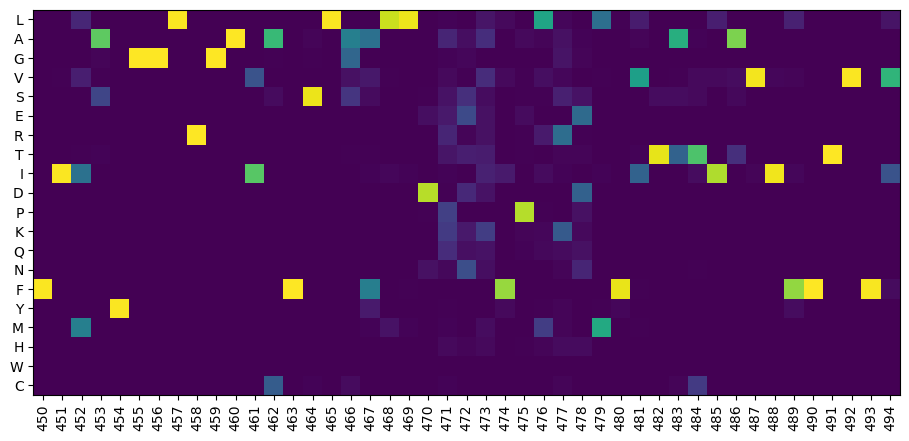

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
si, ei = (450, 495)
plt.imshow(tf_logits[si:ei].cpu().numpy().T)
ax.set_yticks(np.arange(0, 20), list(AA_str))
ax.set_xticks(np.arange(0, ei-si), np.arange(si, ei), rotation=90)
plt.show()

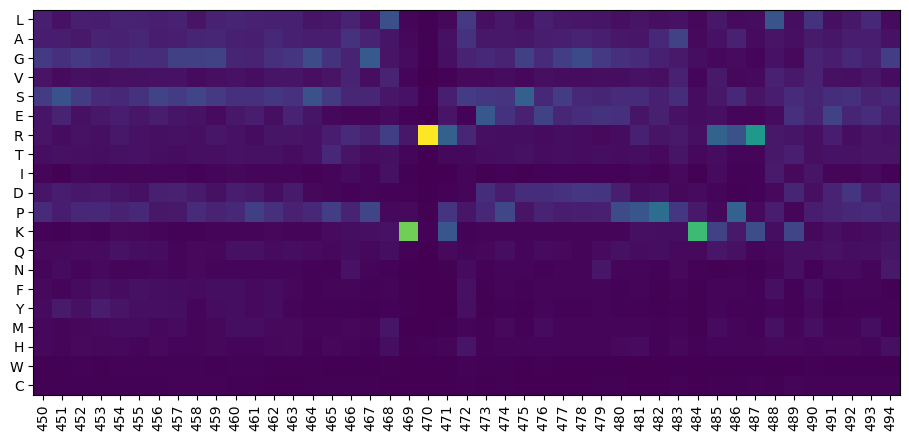

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
si, ei = (450, 495)
plt.imshow(tf_logits[si:ei].cpu().numpy().T)
ax.set_yticks(np.arange(0, 20), list(AA_str))
ax.set_xticks(np.arange(0, ei-si), np.arange(si, ei), rotation=90)
plt.show()

In [64]:
from go_ml.masking import *
def get_logits(seq, batch_size=8, mask_func=mask_indiv):
    seq_ind = torch.LongTensor(tokenizer.encode(seq)).to(device)
    ln = len(seq)
    batch, batch_inds, mut_inds = mask_func(seq_ind, SEQUENCE_MASK_TOKEN)
    bert_eval_l = []
    with torch.no_grad():
        for si in range(0, batch.shape[0], batch_size):
            ei = min(batch.shape[0], si+batch_size)
            x = batch[si:ei, :]
            model_eval = model(x)
            bert_eval = model_eval.logits
            bert_eval_l.append(bert_eval.cpu())
    bert_eval = torch.cat(bert_eval_l)
    # bert_eval = torch.softmax(bert_eval, dim=2)
    bert_mask = (batch == SEQUENCE_MASK_TOKEN).cpu()
    eval_avg, eval_support = mask_avg(bert_mask, bert_eval)
    return eval_avg

rgds_logits = get_logits(sequences[-1], batch_size=16, mask_func=lambda a, b: mask_perc(a, b, 6, 0.15))

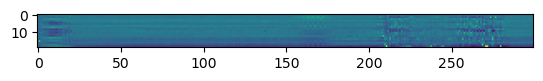

In [68]:
plt.imshow(rgds_logits.cpu().numpy()[:300, 4:24].T)

In [ ]:
def logit_entropy(logit_l, base_ind, max_len=800):
    max_entr = np.log(len(base_ind))
    entropy_val = np.zeros((len(logit_l), max_len+1)) + max_entr
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        entropy_val[i, 1:sl+1] = res_entropy_imp[1:-1].numpy()
    return entropy_val


In [ ]:
tokenizer.tokenize(sequences)


In [ ]:
kmer_stats = torch.zeros(20, 20)
